<a href="https://colab.research.google.com/github/gnganesh99/NN_Error/blob/ayush_dev/notebooks/STM/stm_multiscale_latent_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
Cloning into 'NN_Error'...
remote: Enumerating objects: 574, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 574 (delta 48), reused 11 (delta 7), pack-reused 474 (from 1)
Receiving objects: 100% (574/574), 165.66 MiB | 16.82 MiB/s, done.
Resolving deltas: 100% (332/332), done.
/content/NN_Error/NN_Error
Colab setup complete.


In [37]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [38]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


In [39]:
class Norm_G:
    """Gaussian normalization using mean and standard deviation."""

    def __init__(self, data=None, mean=None, std=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.mean = np.mean(data, axis=axis, keepdims=True)
            self.std = np.std(data, axis=axis, keepdims=True)
        elif mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            raise ValueError("Either data or both mean and std must be provided.")

        self.std = np.where(self.std < eps, eps, self.std)

    def normalize(self, data=None):
        """Normalize data using stored mean and std."""
        if data is None:
            data = self.data
        return (data - self.mean) / self.std

    def denormalize(self, normalized_data):
        """Denormalize data using stored mean and std."""
        return normalized_data * self.std + self.mean


class Norm_0to1:
    """Normalization to the range [0, 1]."""

    def __init__(self, data=None, min_val=None, max_val=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.min_val = np.min(data, axis=axis, keepdims=True)
            self.max_val = np.max(data, axis=axis, keepdims=True)
        elif min_val is not None and max_val is not None:
            self.min_val = min_val
            self.max_val = max_val
        else:
            raise ValueError("Either data or both min_val and max_val must be provided.")

        self.data_range = np.where(
            (self.max_val - self.min_val) < eps,
            eps,
            self.max_val - self.min_val
        )

    def normalize(self, data=None):
        """Normalize data using stored min and max."""
        if data is None:
            if self.data is None:
                raise ValueError("No data provided to normalize.")
            data = self.data

        return (data - self.min_val) / self.data_range

    def denormalize(self, normalized_data):
        """Denormalize data using stored min and max."""
        return normalized_data * self.data_range + self.min_val

# Get data

In [40]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [41]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 200
n_epochs_error = 200
error_type = "L1" # "L1", "L2", or "cos"
model_type = 'im2spec'
append_image_type = 'pad' if model_type == 'im2spec' or 'im2spec_attn' else 'interpolate' #pad, interpolate
last_swa_epochs = 100
latent_dim = 5

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


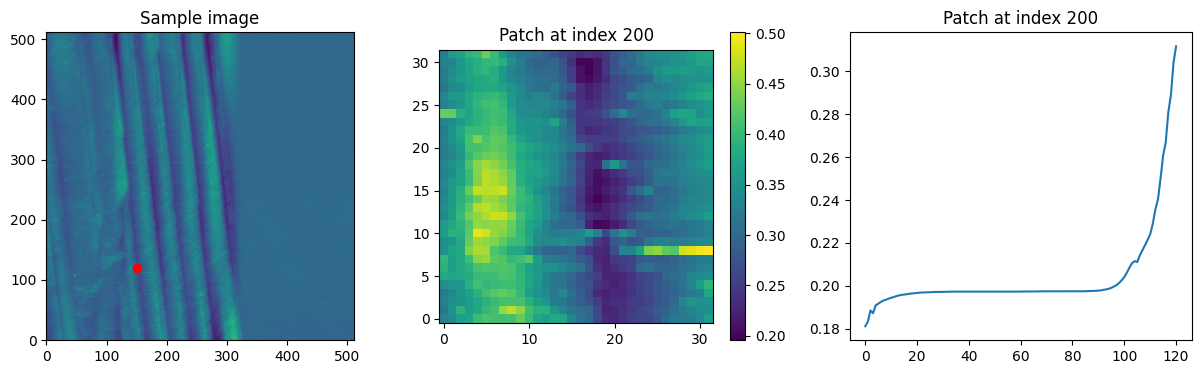

In [42]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [43]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

## Train/test split

In [44]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [45]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, test_size = 0.2, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (819, 32, 32)
images_test shape: (205, 32, 32)
spectra_train shape: (819, 121)
spectra_test shape: (205, 121)


## Augment across scales

In [46]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


In [47]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)
images_train shape: (6552, 32, 32)
images_test shape: (1640, 32, 32)


## Model dimensions

In [48]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (8192, 32, 32)
spectra shape: (8192, 121)


# Train im2spec

## IM2SPEC model

In [49]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=latent_dim,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
      use_swa = use_swa,
      last_swa_epochs = last_swa_epochs,
  ).to(device)

elif model_type == 'im2spec':
  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
elif model_type == 'im2spec_attn':
  imspec_model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)



else:
  raise ValueError(f"Unknown model type: {model_type}")


 55%|█████▌    | 110/200 [03:22<02:45,  1.84s/it, train_loss=0.0012, val_loss=0.0021]
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


Early stopping triggered after 10 epochs!


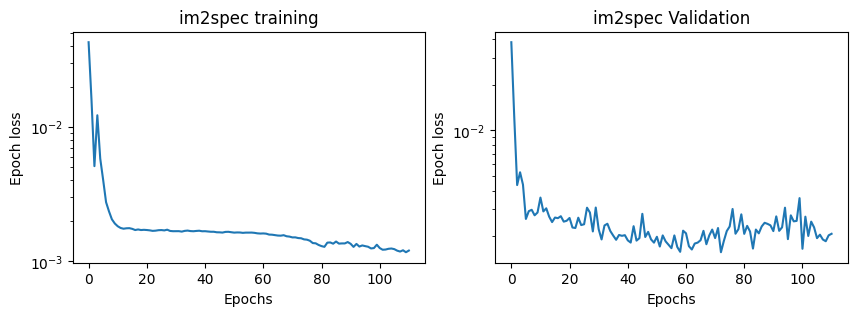

im2spec final train loss: 0.001202896664229532
im2spec final internal val loss: 0.0020732757901506765
im2spec held-out test loss: 0.0022534201852977276


In [50]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
    use_swa = True,
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Estimate error

In [51]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)


print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (6552,)
error_vector shape: (6552, 121)
error_targets shape: (6552, 1)


## Train error model

 50%|█████     | 101/200 [02:06<02:03,  1.25s/it, train_loss=0.0002, val_loss=0.0002]

SWA triggered at epoch 100


 59%|█████▉    | 118/200 [02:28<01:43,  1.26s/it, train_loss=0.0002, val_loss=0.0002]


Early stopping triggered after 10 epochs!
error model final train loss: 0.00018326379982421974
error model final val loss: 0.000192143176848601


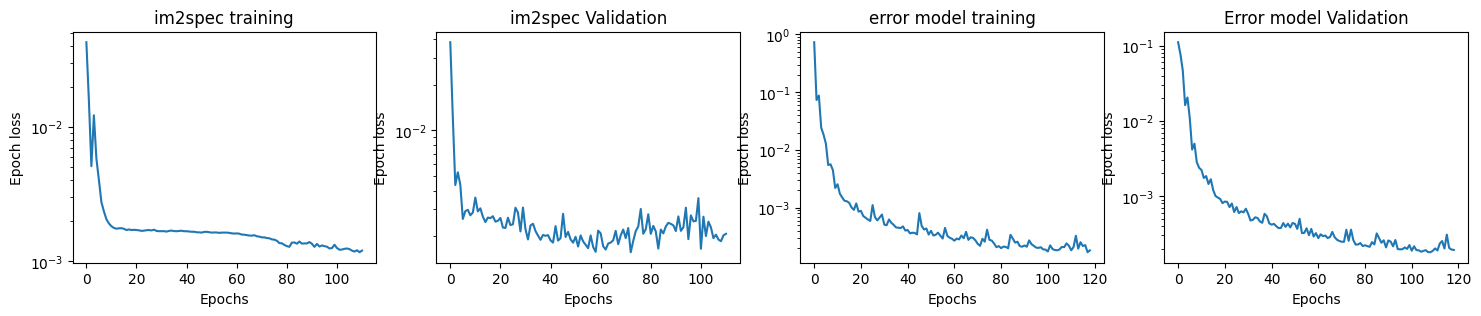

In [52]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
    use_swa = True,
    last_swa_epochs = last_swa_epochs
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [67]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (8192,)
predicted_errors range: 0.0 0.12412059307098389


## Acquisition function

In [62]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra


#beta=0 is explotation. aq_fn is inverse to errors
aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn.shape)


(1640,)


# Visualize acquisition results

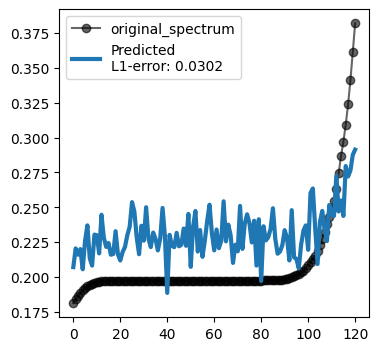

In [63]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1], error_type=error_type)
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean())

## 3D error and acquisition view

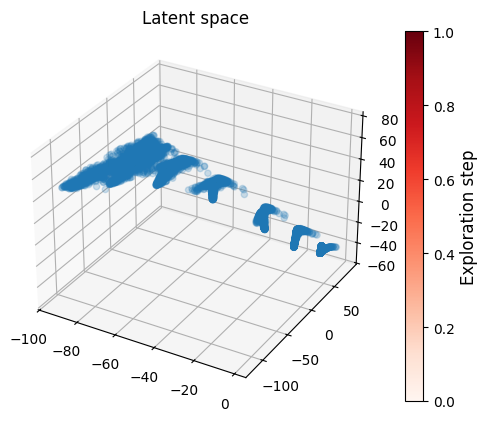

In [64]:
output_type = 'latent'
posterior_spectra = predict_posterior(imspec_model, images, output_type = output_type)
posterior_trainset = predict_posterior(imspec_model, images_train, output_type = output_type)
plot_latent_space(posterior_spectra, posterior_trainset[initial_trainsize:],lat_order = [0, 1, 2])

In [65]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True,
                         colormap="jet", )

ValueError: Length mismatch: coordinates imply 8192 points (nx=32, ny=32, nz=8), but got error_mean of length 1640 and aq_fn of length 1640.

In [58]:
plot_scale_slider(scale_coordinates, predicted_errors, aq_fn, colormap="jet")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Scale', max=7), Output()), _dom…

<function nnerror.plot_functions.plot_scale_slider.<locals>._draw_by_index(scale_index)>

In [59]:
#cluster_latent_space(posterior_spectra, lat_order = [0, 1, 2],  n_clusters = 3) # keep n_clusters < 5

## Scale-specific error maps

NameError: name 'cax1' is not defined

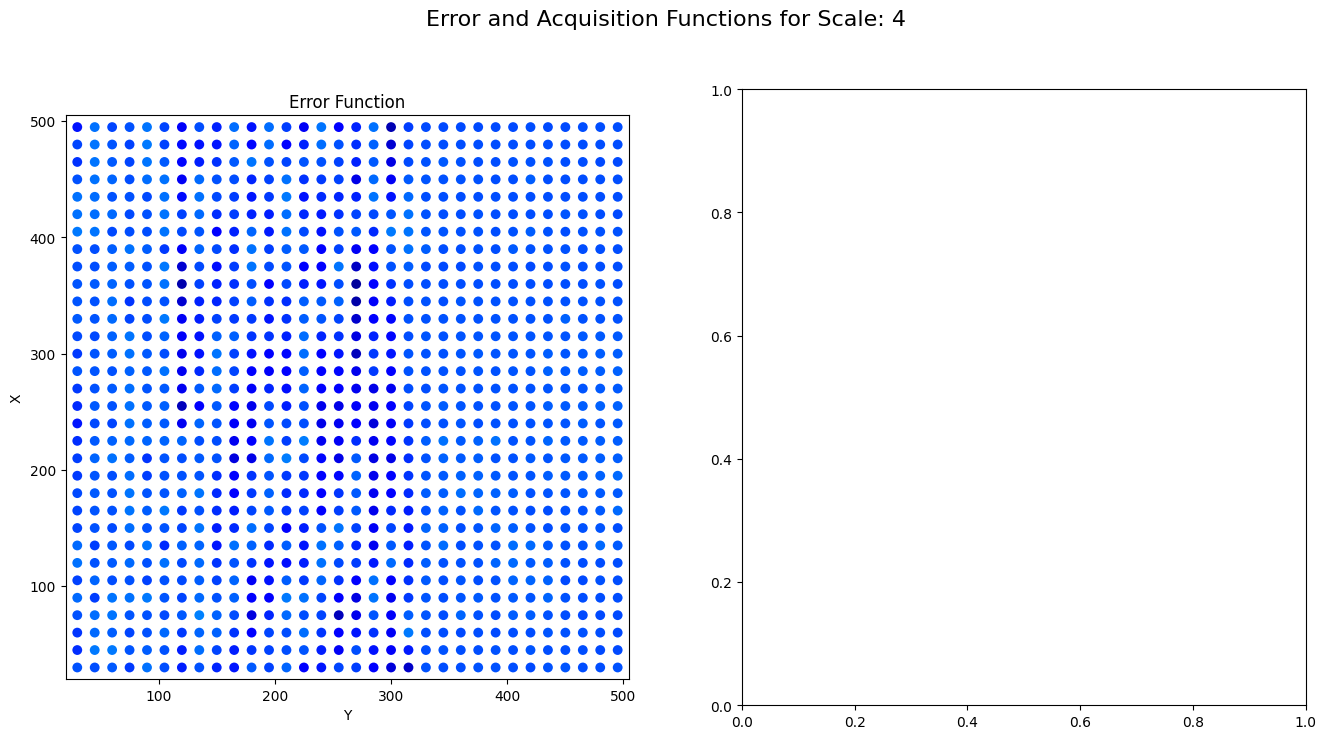

In [60]:
# Call the new plotting function
plot_scale_specific_error_and_acquisition_maps(scale_coordinates, predicted_errors, aq_fn)

unique_scales = np.unique(scale_coordinates[:, 2])
for s in unique_scales[::2]:
  scale_mask = scale_coordinates[:, 2] == s
  latent_space_scaled = posterior_spectra[scale_mask]

  # Latent space plot
  plot_latent_space(latent_space_scaled, posterior_trainset[initial_trainsize:], lat_order = [0,1,2])

  # Clustered latent space plot
  cluster_latent_space(latent_space_scaled, lat_order = [0, 1, 2], n_clusters = 3)
